# Exercise 9: Effect of Non-Random Noise in Input Features

**Authors**:
- Ariful Islam Riane : 3981886
- Pedro Fernandez Tonso : 3983781
- Group Number : 19

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

## 1. Load and Prepare Data

In [2]:
def load_and_prepare_data(file_path):
    ar, _ = arff.loadarff(file_path)
    df = pd.DataFrame(ar).dropna()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].map(lambda x: x.decode() if isinstance(x, bytes) else x)
    return df

file_path = Path('../databank/00_raw/uci-large/credit-a.arff')
if not file_path.exists():
    file_path = Path('dq-lab-1/databank/00_raw/uci-large/credit-a.arff')

data = load_and_prepare_data(file_path)
base_cols = pd.get_dummies(data.drop('class', axis=1)).drop(
    [c for c in pd.get_dummies(data.drop('class', axis=1)).columns if c.endswith('_?')],
    axis=1
).columns

## 2. Evaluation and Noise Injection

In [3]:
def evaluate(df, base_columns, random_state=100):
    X = pd.get_dummies(df.drop('class', axis=1)).reindex(columns=base_columns, fill_value=0)
    y = df['class']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.7, test_size=0.3, random_state=random_state
    )
    clf = GaussianNB().fit(X_train, y_train)
    return accuracy_score(y_test, clf.predict(X_test))

def inject_noise(df, selector_col, selector_val, target_col, noise_level, rng):
    if selector_col == target_col:
        raise ValueError('Selector and target attributes cannot be identical.')
    df_out = df.copy()
    mask = (
        (df_out[selector_col] == selector_val)
        if selector_col is not None
        else np.ones(len(df_out), dtype=bool)
    )
    target_idx = df_out.index[mask].to_numpy()
    n_corrupt = int(len(target_idx) * noise_level)
    if n_corrupt > 0:
        chosen_idx = rng.choice(target_idx, size=n_corrupt, replace=False)
        col = df_out[target_col]
        if col.dtype in ('object', 'str', 'string'):
            df_out.loc[chosen_idx, target_col] = rng.choice(col.dropna().unique(), size=n_corrupt)
        else:
            df_out.loc[chosen_idx, target_col] = rng.uniform(col.min(), col.max(), size=n_corrupt)
    return df_out, len(target_idx), n_corrupt

def run_experiment(df, selector_col, selector_val, target_col, noise_levels=None, base_columns=None, n_seeds=5):
    if selector_col == target_col:
        raise ValueError('Selector and target attributes cannot be identical.')
    if noise_levels is None:
        noise_levels = [round(0.05 * i, 2) for i in range(21)]
    
    target_indices = df.index[df[selector_col] == selector_val].to_numpy()
    n_target = len(target_indices)
    n_total = len(df)
    baseline_acc = evaluate(df, base_columns)
    
    records = []
    for p in noise_levels:
        k = int(n_target * p)
        accs_nr, accs_rand = [], []
        for s in range(n_seeds):
            rng = np.random.default_rng(s)
            df_nr, _, _ = inject_noise(df, selector_col, selector_val, target_col, p, rng)
            accs_nr.append(evaluate(df_nr, base_columns))
            
            df_rand, _, _ = inject_noise(df, None, None, target_col, k / n_total if n_total > 0 else 0, rng)
            accs_rand.append(evaluate(df_rand, base_columns))
            
        records.append({
            'noise_level': p,
            'corrupted_count': k,
            'acc_non_random': float(np.mean(accs_nr)),
            'acc_random_proportional': float(np.mean(accs_rand))
        })
    return pd.DataFrame(records), baseline_acc, n_target, n_total

def plot_noise_comparison(df_res, baseline_acc, selector_col, selector_val, target_col, n_target, n_total):
    plt.figure(figsize=(8, 5))
    p = df_res['noise_level']
    plt.plot(p, df_res['acc_non_random'], marker='o', linewidth=2, label=f'Non-Random ({selector_col}={selector_val})')
    plt.plot(p, df_res['acc_random_proportional'], marker='s', linewidth=1.5, linestyle='--', label='Proportional Random (Matched Count k)')
    plt.axhline(baseline_acc, color='red', linestyle='-.', alpha=0.7, label=f'Baseline (0% noise): {baseline_acc:.4f}')
    plt.title(f'Non-Random vs Proportional Random Noise: Target={target_col} | Selector={selector_col}={selector_val} ({n_target}/{n_total} rows)', fontsize=12)
    plt.xlabel('Noise Level (Proportion of Target Subpopulation Corrupted)', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(round(y*100))}%"))
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

## 3. Experiment: Non-Random Noise in Numerical Feature (A15 Income conditioned on A9='t')

In [4]:
df_num, base_acc_num, n_target_num, n_total_num = run_experiment(
    data, 'A9', 't', 'A15', base_columns=base_cols
)
print(f"Baseline Accuracy: {base_acc_num:.4f} | Target Group Size: {n_target_num}/{n_total_num} ({n_target_num/n_total_num*100:.1f}%)")
df_num.iloc[::2]

Baseline Accuracy: 0.8250 | Target Group Size: 352/666 (52.9%)


,noise_level,corrupted_count,acc_non_random,acc_random_proportional
0,0.0,0,0.825,0.825
2,0.1,35,0.829,0.822
4,0.2,70,0.791,0.798
6,0.3,105,0.776,0.789
8,0.4,140,0.757,0.783
10,0.5,176,0.757,0.758
12,0.6,211,0.776,0.744
14,0.7,246,0.773,0.742
16,0.8,281,0.802,0.737
18,0.9,316,0.788,0.732


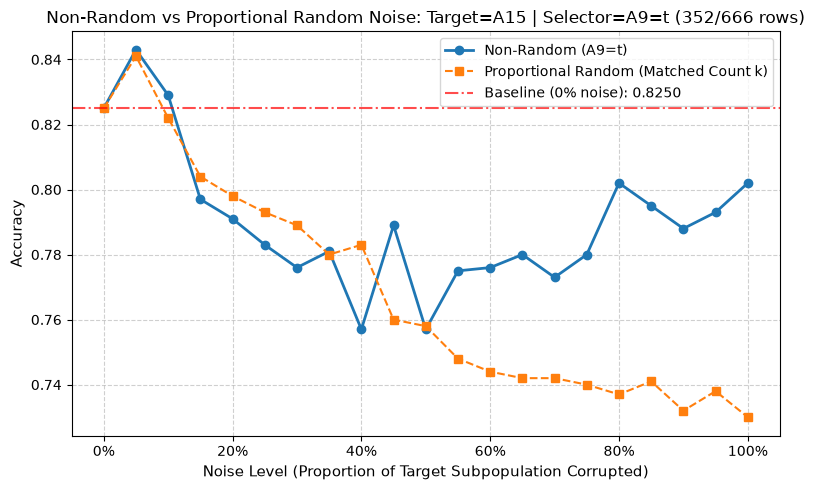

In [5]:
plot_noise_comparison(df_num, base_acc_num, 'A9', 't', 'A15', n_target_num, n_total_num)

## 4. Experiment: Non-Random Noise in Categorical Feature (A9 Prior Default conditioned on A10='f')

In [6]:
df_cat, base_acc_cat, n_target_cat, n_total_cat = run_experiment(
    data, 'A10', 'f', 'A9', base_columns=base_cols
)
print(f"Baseline Accuracy: {base_acc_cat:.4f} | Target Group Size: {n_target_cat}/{n_total_cat} ({n_target_cat/n_total_cat*100:.1f}%)")
df_cat.iloc[::2]

Baseline Accuracy: 0.8250 | Target Group Size: 376/666 (56.5%)


,noise_level,corrupted_count,acc_non_random,acc_random_proportional
0,0.0,0,0.825,0.825
2,0.1,37,0.824,0.819
4,0.2,75,0.823,0.820
6,0.3,112,0.824,0.807
8,0.4,150,0.811,0.804
10,0.5,188,0.809,0.798
12,0.6,225,0.808,0.799
14,0.7,263,0.806,0.796
16,0.8,300,0.800,0.788
18,0.9,338,0.807,0.789


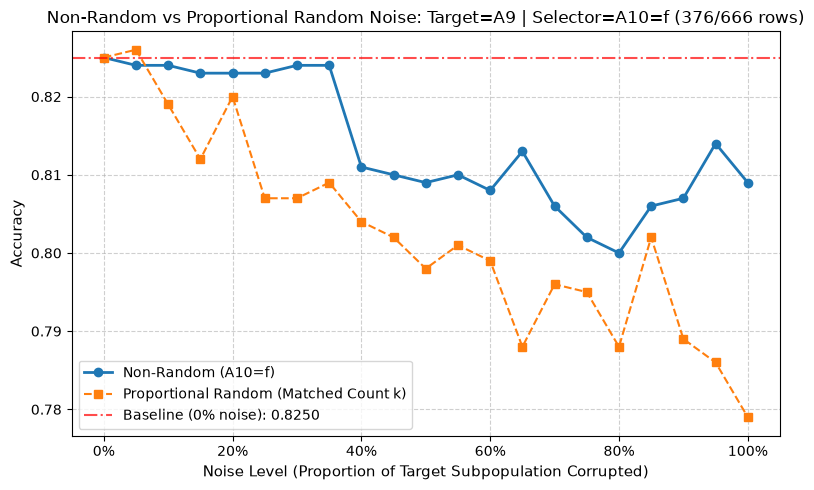

In [7]:
plot_noise_comparison(df_cat, base_acc_cat, 'A10', 'f', 'A9', n_target_cat, n_total_cat)

## Takeaways

Non-random noise restricts corruption to a specific subgroup defined by the selector attribute, leaving the complementary subgroup intact.

When comparing non-random noise against proportional random noise matching the exact corrupted count k, non-random corruption often maintains higher or more localized resilience because the model preserves a clean decision boundary for the uncorrupted subpopulation.